# TSS Activity and Rotation Catalog Merge

In [2]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import pickle

import matplotlib as mpl
mpl.rcParams['font.size'] = 15
mpl.rcParams['axes.labelsize'] = 20


mpl.rc('text', usetex = True)


In [3]:
merged_HPIC = pd.read_csv('HPIC+TSS3.csv')
print(len(merged_HPIC))


for tier in [1,2,3]:
    
    print('"""\nTier{}\n"""'.format(tier))
    tmp = merged_HPIC[merged_HPIC['TSS_tier']==tier]
    totstars = tmp.shape[0]
    print("Number of stars in tier: %i" % tmp.shape[0])
    for key in tmp.keys():
        if ('adopt' in key) or ('calculated' in key):
            try:
                print("Number of valid rows in", key, "column:", np.sum(~np.isnan(tmp[key])), 100*np.sum(~np.isnan(tmp[key])/totstars))
            except(TypeError):
                continue


12944
"""
Tier1
"""
Number of stars in tier: 164
Number of valid rows in vsini_adopt column: 160 97.5609756097561
Number of valid rows in e_vsini_adopt column: 156 95.1219512195122
Number of valid rows in S_index_adopt column: 147 89.6341463414634
Number of valid rows in RHK_adopt column: 123 75.0
Number of valid rows in RHK_calculated_marvin23 column: 147 89.6341463414634
Number of valid rows in RHK_calculated_pyastro column: 130 79.26829268292681
Number of valid rows in prot_adopt column: 115 70.1219512195122
Number of valid rows in act_cycle_adopt column: 28 17.073170731707318
Number of valid rows in phot_jitter_adopt column: 98 59.756097560975604
"""
Tier2
"""
Number of stars in tier: 495
Number of valid rows in vsini_adopt column: 444 89.69696969696967
Number of valid rows in e_vsini_adopt column: 432 87.27272727272725
Number of valid rows in S_index_adopt column: 392 79.19191919191917
Number of valid rows in RHK_adopt column: 311 62.82828282828281
Number of valid rows in RHK_calc

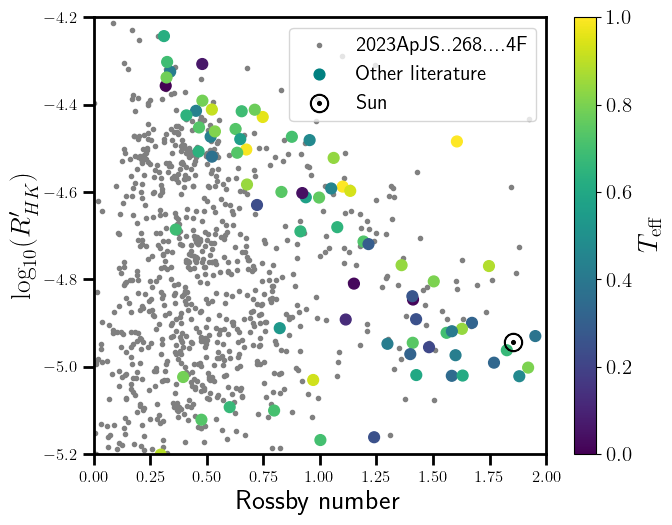

In [17]:
# https://iopscience.iop.org/article/10.1088/0004-637X/741/1/54#apj404215s4 eq 36
tau = 314.24 * np.exp(-(merged_HPIC['Teff']/1952.5) - (merged_HPIC['Teff']/6250.)**18 ) + 0.002

#tau = 10**(0.64+0.25*(merged_HPIC['Vmag']-merged_HPIC['Ksmag']))

TESS = merged_HPIC['r_prot_adopt'] == '2023ApJS..268....4F'
subset = ~TESS 


fig, ax = plt.subplots(figsize=(7,5.5))
ax.tick_params(length=8, width=2, labelsize=12, direction='out')
for xx in ['top','bottom','left','right']:
    ax.spines[xx].set_linewidth(2)

plt.scatter( 
    merged_HPIC['prot_adopt'][TESS ]/tau[TESS], 
    merged_HPIC['RHK_calculated_pyastro'][TESS],  
            c='gray', marker='.', label='2023ApJS..268....4F')
plt.scatter( 
    merged_HPIC['prot_adopt'][subset]/tau[subset],
    merged_HPIC['RHK_calculated_pyastro'][subset], 
    c=merged_HPIC['Teff'][subset], s=60, 
    vmin=4400, vmax=6300)
plt.scatter( 
    0, 0, c='teal', s=60, label='Other literature')

plt.colorbar(label=r'$T_\mathrm{eff}$')


tausun = 314.24 * np.exp(-(5700/1952.5) - (5700/6250.)**18 ) + 0.002
plt.scatter(26/tausun, -4.9427,  marker=r'$\odot$', c='k', s=170, label='Sun')


plt.legend()
plt.xlabel('Rossby number')
plt.ylabel(r'$\log_{10}(R^\prime_{HK})$')
plt.xlim(0,2)
plt.ylim(-5.2,-4.2)
plt.tight_layout()
plt.savefig('rotation-activity.png')

### merged_HPIC.columns

[-4.87487154 -4.88477482 -4.90743905 -4.91045373 -4.91594215 -4.94952178
 -4.98201267 -5.00892467 -5.01152091 -5.04049514 -5.05382093 -5.0500909 ]


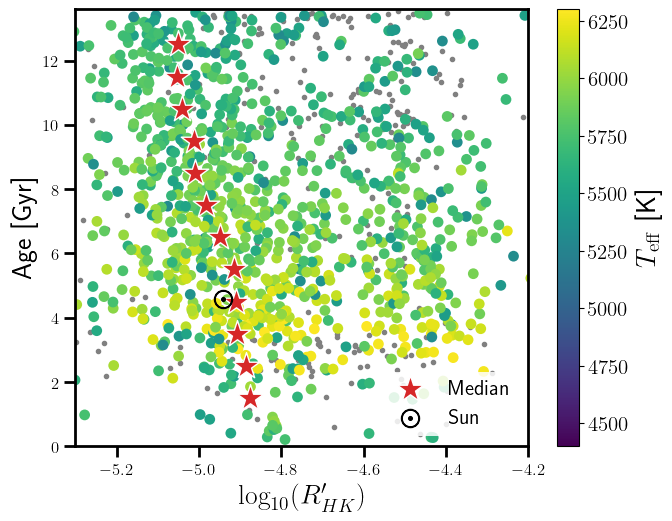

In [18]:
cname = 'RHK_calculated_pyastro'
from scipy.stats import median_abs_deviation
from astropy.stats import sigma_clip  

fig, ax = plt.subplots(figsize=(7,5.5))

use = (merged_HPIC['Teff']>5300.) &  (merged_HPIC['Teff']<6300.)
sc = plt.scatter(
    merged_HPIC[cname][use],
    merged_HPIC['Age'][use],
    c=merged_HPIC['Teff'][use],
    cmap='viridis',
    s=60,
    edgecolor='None',
    linewidth=0.3,
    alpha=1,
    vmin=4400, vmax=6300
)
plt.plot(
    merged_HPIC[cname][~use],
    merged_HPIC['Age'][~use],
    '.', zorder=0,
    c='gray') #, label=r'$T_\mathrm{eff}$ out of range')
plt.colorbar(sc, label=r'$T_\mathrm{eff}$ [K]')

plt.ylim(merged_HPIC['Age'].min() - 0.5, merged_HPIC['Age'].max() + 0.5)
plt.xlabel(r'$\log_{10}(R^\prime_{HK})$')
plt.ylabel('Age [Gyr]')

ax.tick_params(length=8, width=2, labelsize=12, direction='out')
for xx in ['top','bottom','left','right']:
    ax.spines[xx].set_linewidth(2)
    
# ----------------------------------------------------------------------
# Bin in 1‑Gyr intervals & reject outliers -----------------------------
# ----------------------------------------------------------------------
age_bins = np.arange(1, 14, 1)                 
age_bin_centers = (age_bins[:-1] + age_bins[1:]) / 2.0

# Prepare containers for the binned statistics
med_RHK   = []   # median of RHK in each bin (after clipping)
err_low   = []   # 16th percentile – median  (lower error bar)
err_high  = []   # 84th percentile – median  (upper error bar)
num_used  = []   # how many points survived clipping in each bin

for lo, hi in zip(age_bins[:-1], age_bins[1:]):
    # Select the slice belonging to this age bin

    diff = np.log10(merged_HPIC['Age']*1e9)-(-2.*merged_HPIC[cname]-0.1)
    in_bin = merged_HPIC[(merged_HPIC['Age'] >= lo) & (merged_HPIC['Age'] < hi) & use &
                         ( merged_HPIC[cname] < -4.7)]

    # If there are too few points, just skip the bin
    if len(in_bin) < 3:
        med_RHK.append(np.nan)
        err_low.append(np.nan)
        err_high.append(np.nan)
        num_used.append(0)
        continue

    good_vals = in_bin[cname]
    # ------------------------------------------------------------------
    # Robust statistics for the bin
    # ------------------------------------------------------------------
    median_val = np.nanmedian(good_vals)
    p16, p84 = np.percentile(good_vals, [16, 84])
    med_RHK.append(median_val)
    err_low.append(median_val - p16)   # lower error bar
    err_high.append(p84 - median_val) # upper error bar
    num_used.append(len(good_vals))

# Convert to numpy arrays for easy indexing
med_RHK   = np.array(med_RHK)
err_low   = np.array(err_low)
err_high  = np.array(err_high)

print(med_RHK)
# ----------------------------------------------------------------------
# Plot the binned medians with asymmetric errorbars --------------------
# ----------------------------------------------------------------------
# We only plot the bins that contain at least one good point
valid = ~np.isnan(med_RHK)
plt.scatter(
    med_RHK[valid],
    age_bin_centers[valid],
    marker='*',
    s=400, fc='C3', ec='white',
    label='Median' # 1‑Gyr bin median 
)

# Optional: show how many points went into each bin
#for x, y, n in zip(med_RHK[valid], age_bin_centers[valid], np.array(num_used)[valid]):
#    plt.text(x, y, f'{n:d}', ha='center', va='bottom', fontsize=10, color='gray')

plt.scatter(-4.9427, 4.5687, marker=r'$\odot$', c='k', s=170, label='Sun')

plt.xlim(-5.3,-4.2)
ax.legend(
    loc='lower right',           
    frameon=True,
    facecolor='white',
    edgecolor='none',
    framealpha=0.85,
)
plt.tight_layout()

x = np.linspace(-4,-5.2)
logtau = -2.*x
#logtau = -38.053 -17.912*x - 1.6675*x**2
#plt.plot(x, 10**logtau*1e-9, color='C3')


plt.ylim(0,13.6)
plt.savefig('activity-age.png')